In [1]:
import os
import pickle
from forge_multidrug import MultiDrugFORGE
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_absolute_error
from matplotlib import rcParams

# === 0. Plot Settings (Matches your reference) ===
rcParams['pdf.fonttype'] = 42 
rcParams['ps.fonttype'] = 42   
rcParams['font.family'] = 'DejaVu Sans'

In [2]:
dep_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Dep.csv"
ic50_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Creammist_common_ic50.csv"
dep_data = pd.read_csv(dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(ic50_path, header = 0, index_col = 0)
ic50_data = ic50_data.T

In [3]:
joint_model_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/EGFR_multiDrugFORGE_optuna100.pkl"

In [4]:
multidrug_model = MultiDrugFORGE.load_forge(joint_model_path)

In [5]:
exp_data = pd.read_csv(multidrug_model.exp_path, header = 0, index_col = 0)

In [6]:
with open(joint_model_path, 'rb') as f:
        multidrug_model_i = pickle.load(f)

In [7]:
[attr for attr in dir(multidrug_model_i) if not attr.startswith("_")]

['W',
 'dep_data',
 'dep_path',
 'drugs',
 'exp_data',
 'exp_hcg',
 'exp_path',
 'get_train_val_test_kSplits',
 'hD',
 'hI',
 'hcg_list',
 'ic50_data',
 'ic50_path',
 'initialise_model',
 'load_forge',
 'mean_dep',
 'mean_exp',
 'mean_ic50',
 'optuna_tuner',
 'run_Pipeline',
 'save_forge',
 'std_exp',
 'target',
 'test_cellLines',
 'train_cellLines',
 'train_forge',
 'train_instance',
 'training_cv_splits',
 'validate_instance']

In [8]:
exp_data = pd.read_csv(multidrug_model.exp_path, header = 0, index_col = 0)
dep_data = pd.read_csv(multidrug_model.dep_path, header = 0, index_col = 0)
ic50_data = pd.read_csv(multidrug_model.ic50_path, header = 0, index_col = 0)
ic50_data = multidrug_model.ic50_data.T
exp_data.shape, dep_data.shape, ic50_data.shape

((1076, 16289), (1076, 17916), (1325, 187))

In [9]:
common_cellLines = list(set(exp_data.index) & set(dep_data.index) & set(ic50_data.index))
len(common_cellLines)

700

In [10]:
multidrug_model.drugs


['ERLOTINIB', 'GEFITINIB']

In [11]:
exp_data_subset = exp_data.loc[common_cellLines, multidrug_model.hcg_list].drop_duplicates(keep='first')
dep_target = dep_data.loc[common_cellLines, multidrug_model.target].dropna().drop_duplicates(keep='first')
drug_ic50 = ic50_data.loc[common_cellLines, multidrug_model.drugs].dropna().drop_duplicates(keep='first')
exp_data_subset = exp_data.loc[dep_target.index, multidrug_model.hcg_list]
exp_data_subset.shape, dep_target.shape, drug_ic50.shape

((699, 257), (699,), (661, 2))

In [12]:
common_train_cellLines = list(set(multidrug_model.train_cellLines) & set(multidrug_model.exp_data.index))
common_test_cellLines = list(set(multidrug_model.test_cellLines) & set(multidrug_model.exp_data.index))

In [13]:
multidrug_model.exp_data = exp_data_subset
multidrug_model.dep_data = dep_target
multidrug_model.ic50_data = drug_ic50
multidrug_model.exp_data.shape, multidrug_model.dep_data.shape, multidrug_model.ic50_data.shape

((699, 257), (699,), (661, 2))

In [14]:
# Filter train/test cell lines to only include those in the final dataset
common_train_cellLines_filtered = [cl for cl in common_train_cellLines if cl in multidrug_model.exp_data.index]
common_test_cellLines_filtered = [cl for cl in common_test_cellLines if cl in multidrug_model.exp_data.index]

G_train = multidrug_model.exp_data.loc[
    common_train_cellLines_filtered, multidrug_model.hcg_list
].to_numpy()

G_test = multidrug_model.exp_data.loc[
    common_test_cellLines_filtered, multidrug_model.hcg_list
].to_numpy()

D_train = multidrug_model.dep_data.loc[
    common_train_cellLines_filtered
].to_numpy().reshape(-1, 1)

D_test = multidrug_model.dep_data.loc[
    common_test_cellLines_filtered
].to_numpy().reshape(-1, 1)

I_train = multidrug_model.ic50_data.loc[
    common_train_cellLines_filtered, multidrug_model.drugs
].to_numpy()

I_test = multidrug_model.ic50_data.loc[
    common_test_cellLines_filtered, multidrug_model.drugs
].to_numpy()


In [15]:
# Latent embeddings
Z_train = G_train @ multidrug_model.W
Z_test  = G_test  @ multidrug_model.W

# Predictions
pred_D_train = Z_train @ multidrug_model.hD
pred_D_test  = Z_test  @ multidrug_model.hD

pred_I_train = Z_train @ multidrug_model.hI
pred_I_test  = Z_test  @ multidrug_model.hI

# Check drug names to identify column indices
print(f"Drugs: {multidrug_model.drugs}")
print(f"pred_I_train shape: {pred_I_train.shape}")
print(f"I_train shape: {I_train.shape}")


Drugs: ['ERLOTINIB', 'GEFITINIB']
pred_I_train shape: (528, 2)
I_train shape: (528, 2)


In [16]:
# === Plot aesthetics
sns.set(style="white", context="talk", font_scale=1.1)

def concordance_index(y_true, y_pred):
    """Calculate concordance index (C-index)"""
    from scipy.stats import kendalltau
    tau, _ = kendalltau(y_true, y_pred)
    return (tau + 1) / 2

def annotate_and_regress(ax, x, y, title, xlabel, ylabel):
    x = x.flatten()
    y = y.flatten()

    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)
    ci = concordance_index(x, y)
    
    sns.regplot(
        x=x,
        y=y,
        ax=ax,
        color='darkslategrey',  # Line + CI color
        scatter_kws={'s': 40, 'alpha': 1, 'color': 'seagreen','rasterized': True, 'edgecolors': 'black', 'linewidths': 0.1},
        line_kws={'color': 'darkslategrey'},
        ci=95
    )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    metrics = (
        f"Pearson r   = {pearson_corr:.2f}\n"
        f"Spearman ρ  = {spearman_corr:.2f}\n"
        f"R² Score    = {r2:.2f}\n"
        f"MAE         = {mae:.2f}\n"
        f"C-Index     = {ci:.2f}"
    )

    ax.text(
        0.05, 0.95, metrics,
        transform=ax.transAxes,
        fontsize=11,
        va="top", ha='left',
        bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=0.9)
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)
    ax.tick_params(axis='both', which='major', labelsize=12)


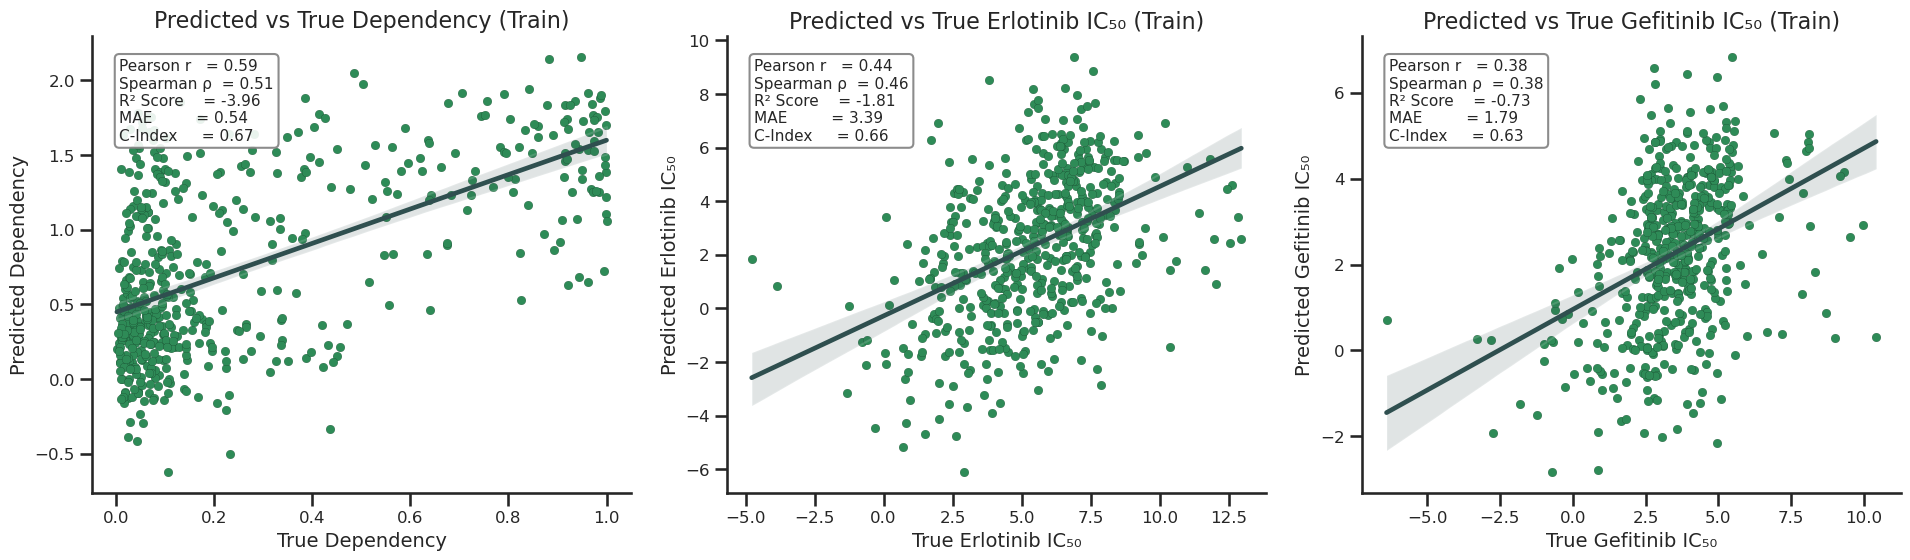

In [17]:
# === TRAIN SET PLOTS (3 panels: Dependency, Erlotinib IC50, Gefitinib IC50) ===
fig_train, axes_train = plt.subplots(1, 3, figsize=(19.5, 6))

# Panel 1: Dependency (Train)
annotate_and_regress(
    axes_train[0],
    D_train,
    pred_D_train,
    "Predicted vs True Dependency (Train)",
    "True Dependency",
    "Predicted Dependency"
)

# Panel 2: Erlotinib IC50 (Train) - assuming column 0
annotate_and_regress(
    axes_train[1],
    I_train[:, 0],
    pred_I_train[:, 0],
    "Predicted vs True Erlotinib IC₅₀ (Train)",
    "True Erlotinib IC₅₀",
    "Predicted Erlotinib IC₅₀"
)

# Panel 3: Gefitinib IC50 (Train) - assuming column 1
annotate_and_regress(
    axes_train[2],
    I_train[:, 1],
    pred_I_train[:, 1],
    "Predicted vs True Gefitinib IC₅₀ (Train)",
    "True Gefitinib IC₅₀",
    "Predicted Gefitinib IC₅₀"
)

plt.tight_layout()
#fig_train.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/pred_vs_true_train_multidrug.pdf", dpi=300, bbox_inches='tight')
plt.show()


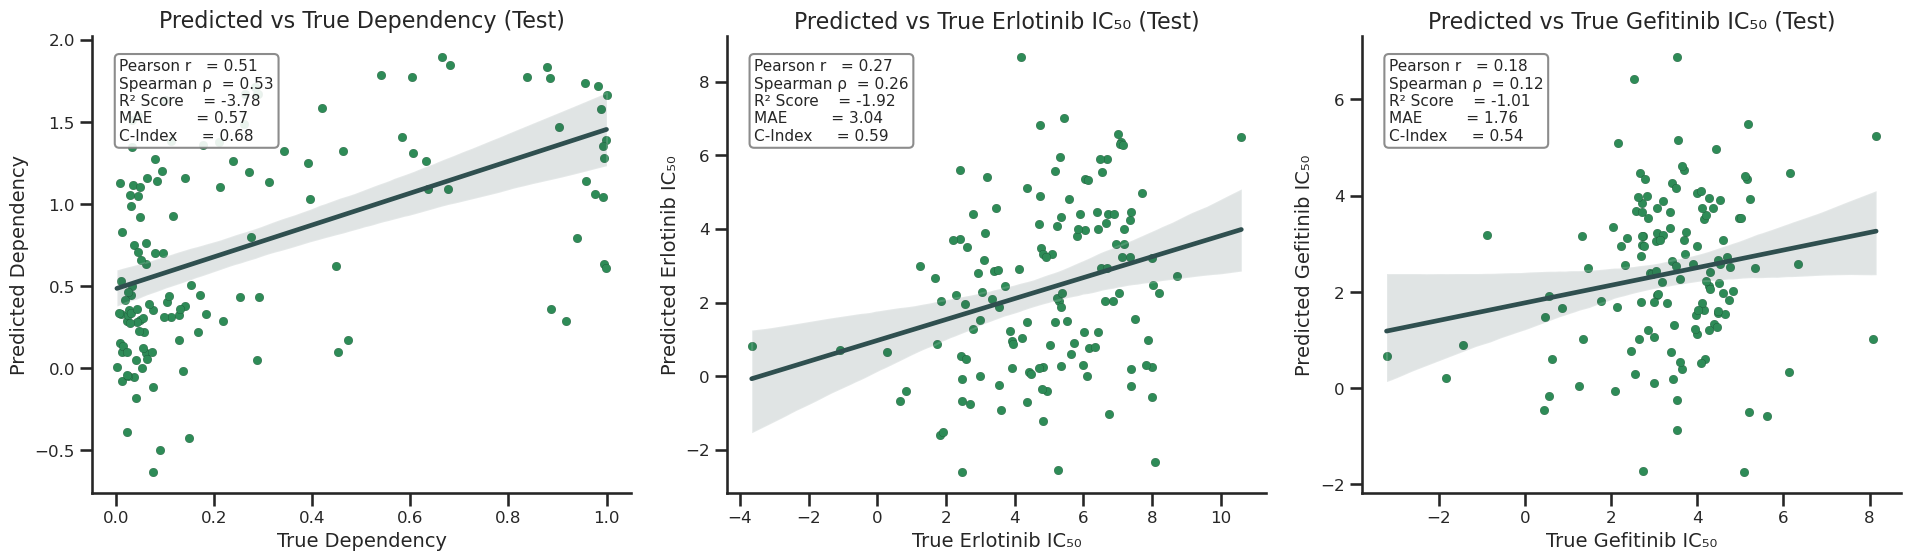

In [19]:
# === TEST SET PLOTS (3 panels: Dependency, Erlotinib IC50, Gefitinib IC50) ===
fig_test, axes_test = plt.subplots(1, 3, figsize=(19.5, 6))

# Panel 1: Dependency (Test)
annotate_and_regress(
    axes_test[0],
    D_test,
    pred_D_test,
    "Predicted vs True Dependency (Test)",
    "True Dependency",
    "Predicted Dependency"
)

# Panel 2: Erlotinib IC50 (Test) - assuming column 0
annotate_and_regress(
    axes_test[1],
    I_test[:, 0],
    pred_I_test[:, 0],
    "Predicted vs True Erlotinib IC₅₀ (Test)",
    "True Erlotinib IC₅₀",
    "Predicted Erlotinib IC₅₀"
)

# Panel 3: Gefitinib IC50 (Test) - assuming column 1
annotate_and_regress(
    axes_test[2],
    I_test[:, 1],
    pred_I_test[:, 1],
    "Predicted vs True Gefitinib IC₅₀ (Test)",
    "True Gefitinib IC₅₀",
    "Predicted Gefitinib IC₅₀"
)

plt.tight_layout()
#fig_test.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/pred_vs_true_test_multidrug.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [20]:
# Combine train + test for all cell lines
cell_lines = common_train_cellLines_filtered + common_test_cellLines_filtered
set_labels = ["train"] * len(common_train_cellLines_filtered) + ["test"] * len(common_test_cellLines_filtered)
# Actual values
D_all = np.concatenate([D_train.flatten(), D_test.flatten()])
I_all = np.concatenate([I_train, I_test], axis=0)
# Predicted values
pred_D_all = np.concatenate([pred_D_train.flatten(), pred_D_test.flatten()])
pred_I_all = np.concatenate([pred_I_train, pred_I_test], axis=0)
# Build DataFrame
df_results = pd.DataFrame({
    "Cell_line": cell_lines,
    "set": set_labels,
    "Actual_I_ERLOTINIB": I_all[:, 0],
    "PredI_ERLOTINIB": pred_I_all[:, 0],
    "Actual_I_GEFITINIB": I_all[:, 1],
    "PredI_GEFITINIB": pred_I_all[:, 1],
    "Actual_D": D_all,
    "PredD": pred_D_all
})
# Save
output_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/predictions_EGFR_multiDrugFORGE.csv"
df_results.to_csv(output_path, index=False)
print(f"Saved {len(df_results)} rows to {output_path}")
df_results.head()

Saved 660 rows to /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/predictions_EGFR_multiDrugFORGE.csv


,Cell_line,set,Actual_I_ERLOTINIB,PredI_ERLOTINIB,Actual_I_GEFITINIB,PredI_GEFITINIB,Actual_D,PredD
0,G402,train,6.43137,6.505050,4.69395,4.852468,0.077956,0.248759
1,SUPM2,train,5.01287,2.572859,4.32062,3.344207,0.023470,-0.124466
2,SW837,train,2.87236,0.352037,2.95591,0.365423,0.580508,1.394484
3,SNU685,train,7.25057,5.392735,4.98124,2.623167,0.071963,0.061259
4,U2OS,train,5.68563,2.737259,5.04528,1.160771,0.196038,0.189180


### Calculate gene influence dataframe 

In [21]:
# %%
# === 1. Calculate Gene Influence ===
# Influence = W (Gene weights) @ hI (Drug-specific weights)
# Shape: (n_genes, n_latent) @ (n_latent, n_drugs) -> (n_genes, n_drugs)

influence_matrix = multidrug_model.W @ multidrug_model.hI

# Create DataFrame
gene_influence_df = pd.DataFrame(
    influence_matrix,
    index=multidrug_model.hcg_list,
    columns=multidrug_model.drugs
)
gene_influence_df["Gene"] = gene_influence_df.index

# Inspect
print("Drugs found:", multidrug_model.drugs)
gene_influence_df.head()

Drugs found: ['ERLOTINIB', 'GEFITINIB']


,ERLOTINIB,GEFITINIB,Gene
DSG2-AS1,-0.039436,-0.016842,DSG2-AS1
ARHGEF5,0.019008,0.003601,ARHGEF5
P2RY2,-0.043807,-0.048833,P2RY2
SH2D3A,0.001362,-0.003323,SH2D3A
CALU,-0.008531,0.012092,CALU


### Gene influence scatter plot 

In [ ]:
df

,ERLOTINIB,GEFITINIB,Gene
DSG2-AS1,-0.681390,-0.419188,DSG2-AS1
ARHGEF5,0.213293,-0.007340,ARHGEF5
P2RY2,-0.748296,-1.063681,P2RY2
SH2D3A,-0.056848,-0.146827,SH2D3A
CALU,-0.208291,0.163704,CALU
...,...,...,...
INAVA,-1.447794,-1.443881,INAVA
FRK,-0.194224,-0.146486,FRK
P3H1,0.127381,-0.587297,P3H1
PRRG4,1.408309,1.794296,PRRG4


Plotting influence for: ERLOTINIB vs GEFITINIB


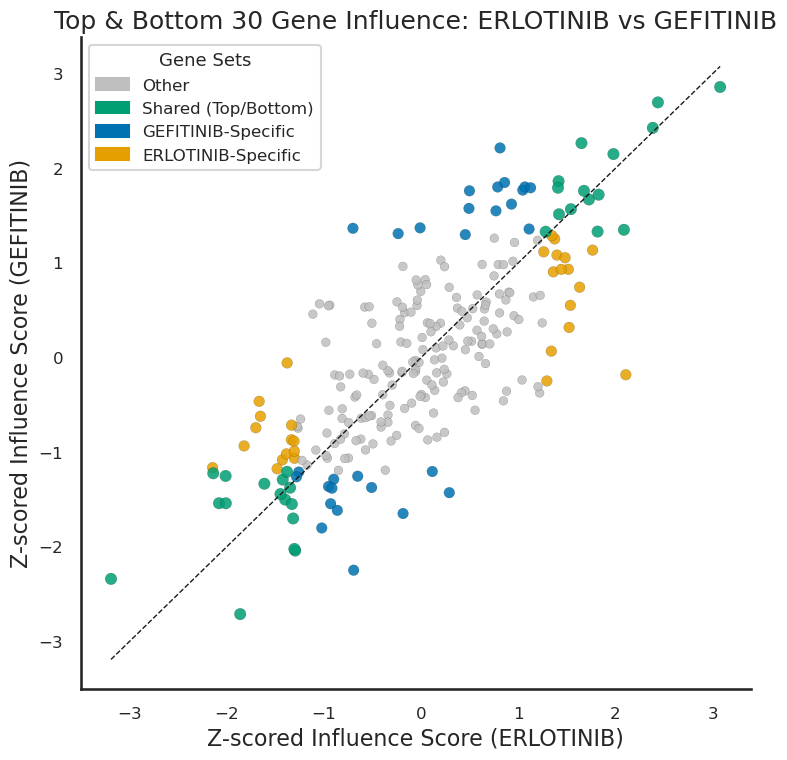

In [22]:
# %%
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler

# === Parameters ===
top_n = 30
bottom_n = 30

# Dynamically select the first two drugs from the model
drug1 = multidrug_model.drugs[0]  # likely 'ERLOTINIB' or similar
drug2 = multidrug_model.drugs[1]  # likely 'GEFITINIB' or similar

print(f"Plotting influence for: {drug1} vs {drug2}")

# === Copy and scale influence scores ===
df = gene_influence_df.copy()
scaler = StandardScaler()
df[[drug1, drug2]] = scaler.fit_transform(df[[drug1, drug2]])

# === Extract top and bottom genes post-scaling ===
# Note: We use the drug names directly as column headers now
top_genes_d1 = set(df.nlargest(top_n, drug1)["Gene"])
bottom_genes_d1 = set(df.nsmallest(bottom_n, drug1)["Gene"])
top_genes_d2 = set(df.nlargest(top_n, drug2)["Gene"])
bottom_genes_d2 = set(df.nsmallest(bottom_n, drug2)["Gene"])

highlight_d1 = top_genes_d1.union(bottom_genes_d1)
highlight_d2 = top_genes_d2.union(bottom_genes_d2)

# === Categorize genes ===
shared = highlight_d1 & highlight_d2
unique_d1 = highlight_d1 - highlight_d2
unique_d2 = highlight_d2 - highlight_d1

# === Color palette: Set2 ===
set2_colors = sns.color_palette("Set2", 3)
color_map = {
    "shared": "#009E73",   # bluish green
    "d1": "#E69F00",       # orange
    "d2": "#0072B2",       # blue
    "other": "#BFBFBF"     # light gray
}

# === Prepare plotting data ===
x = df[drug1]
y = df[drug2]
genes = df["Gene"]

colors = []
sizes = []
for gene in genes:
    if gene in shared:
        colors.append(color_map["shared"])
        sizes.append(70)
    elif gene in unique_d1:
        colors.append(color_map["d1"])
        sizes.append(60)
    elif gene in unique_d2:
        colors.append(color_map["d2"])
        sizes.append(60)
    else:
        colors.append(color_map["other"])
        sizes.append(40)

# === Plot ===
plt.figure(figsize=(8, 8))
plt.scatter(
    x, y, c=colors, s=sizes, alpha=0.85,
    edgecolors='black', linewidth=0.1, rasterized=True
)

# Identity line
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

# Labels and title
# Clean up drug names for display if they have suffixes like '_ic50'
d1_label = drug1.replace("_ic50", "")
d2_label = drug2.replace("_ic50", "")

plt.xlabel(f"Z-scored Influence Score ({d1_label})", fontsize=16)
plt.ylabel(f"Z-scored Influence Score ({d2_label})", fontsize=16)
plt.title(f"Top & Bottom {top_n} Gene Influence: {d1_label} vs {d2_label}", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Despine top and right
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color=color_map["other"], label="Other"),
    mpatches.Patch(color=color_map["shared"], label="Shared (Top/Bottom)"),
    mpatches.Patch(color=color_map["d2"], label=f"{d2_label}-Specific"),
    mpatches.Patch(color=color_map["d1"], label=f"{d1_label}-Specific"),
]
plt.legend(handles=legend_patches, title="Gene Sets", loc='upper left', fontsize=12, title_fontsize=13)

plt.grid(False)
plt.tight_layout()
# Optional: save figure
#plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/multidrug_gene_influence_scatter.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [24]:
df.to_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/multidrug_scatterplot.csv", index=False)

### Residual Distribution Plot 

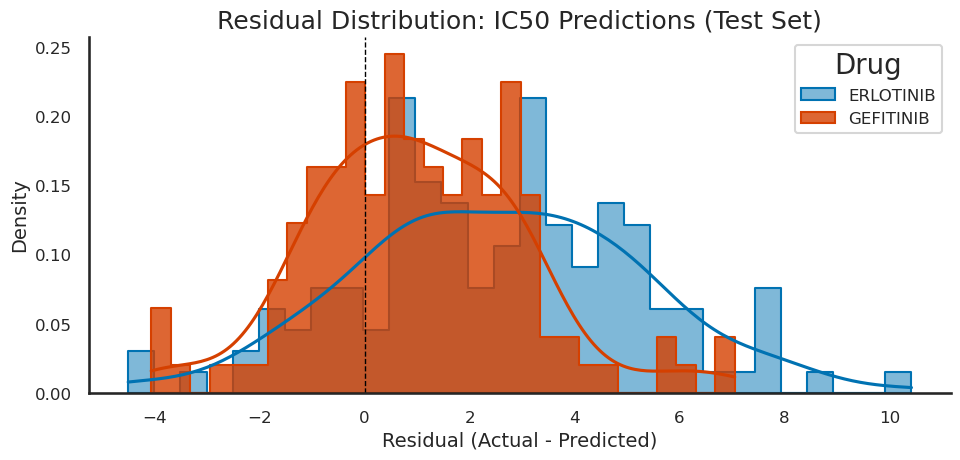

In [ ]:
# === Identify Indices ===
# multidrug_model.drugs defines the column order for I_test and pred_I_test
drug1_name = multidrug_model.drugs[0]
drug2_name = multidrug_model.drugs[1]

idx1 = 0
idx2 = 1

# === Calculate Residuals (Actual - Predicted) ===
# I_test and pred_I_test are numpy arrays (n_samples, n_drugs)
residuals_d1 = I_test[:, idx1] - pred_I_test[:, idx1]
residuals_d2 = I_test[:, idx2] - pred_I_test[:, idx2]

# === Colors from Set2 palette ===
set2 = sns.color_palette("Set2")
color_d1 = "#0072B2"  # blue
color_d2 = "#D54000"  # vermillion (reddish-orange)

# === Plot ===
plt.figure(figsize=(10, 5))

# Plot Histograms
sns.histplot(
    residuals_d1,
    color=color_d1,
    kde=True,
    label=drug1_name.replace("_ic50", ""),
    stat="density",
    bins=30,
    alpha=0.5,
    element="step",   # already good
    fill=True        # 🔥 key: removes fill ambiguity
)

sns.histplot(
    residuals_d2,
    color=color_d2,
    kde=True,
    label=drug2_name.replace("_ic50", ""),
    stat="density",
    bins=30,
    alpha=0.8,
    element="step",
    fill=True
)

plt.axvline(0, color='black', linestyle='--', lw=1)

# === Labels and aesthetics ===
plt.title("Residual Distribution: IC50 Predictions (Test Set)", fontsize=18)
plt.xlabel("Residual (Actual - Predicted)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, title="Drug")
plt.grid(False)
sns.despine()
plt.tight_layout()

# Optional: Save figure
plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/multidrug_residual_distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()